In [ ]:
import pandas as pd

df = pd.read_csv('/content/PhiUSIIL_Phishing_URL_Dataset.csv')

print("First 5 rows of the DataFrame:")
print(df.head())

print("\nDataFrame Info:")
df.info()

print("\nDescriptive Statistics:")
print(df.describe())

print("\nMissing values per column:")
print(df.isnull().sum())

First 5 rows of the DataFrame:
     FILENAME                                 URL  URLLength  \
0  521848.txt    https://www.southbankmosaics.com         31   
1   31372.txt            https://www.uni-mainz.de         23   
2  597387.txt      https://www.voicefmradio.co.uk         29   
3  554095.txt         https://www.sfnmjournal.com         26   
4  151578.txt  https://www.rewildingargentina.org         33   

                       Domain  DomainLength  IsDomainIP  TLD  \
0    www.southbankmosaics.com            24           0  com   
1            www.uni-mainz.de            16           0   de   
2      www.voicefmradio.co.uk            22           0   uk   
3         www.sfnmjournal.com            19           0  com   
4  www.rewildingargentina.org            26           0  org   

   URLSimilarityIndex  CharContinuationRate  TLDLegitimateProb  ...  Pay  \
0               100.0              1.000000           0.522907  ...    0   
1               100.0              0.666667    

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
X = df.drop('label', axis=1)
y = df['label']

columns_to_drop = ['FILENAME', 'URL', 'Domain', 'Title']
X = X.drop(columns=columns_to_drop)

categorical_features = ['TLD']
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()


if 'TLD' in numerical_features:
    numerical_features.remove('TLD')


X_categorical = pd.get_dummies(X[categorical_features], columns=categorical_features, drop_first=True)

scaler = StandardScaler()
X_numerical_scaled = scaler.fit_transform(X[numerical_features])
X_numerical_scaled = pd.DataFrame(X_numerical_scaled, columns=numerical_features, index=X.index)

X_processed = pd.concat([X_numerical_scaled, X_categorical], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)
print("Data preprocessing complete.")

Shape of X_train: (188636, 744)
Shape of X_test: (47159, 744)
Shape of y_train: (188636,)
Shape of y_test: (47159,)
Data preprocessing complete.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier

print("Classifiers imported successfully.")

# Initialize and train Logistic Regression model
lr_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
lr_model.fit(X_train, y_train)
print("Logistic Regression model trained.")

# Initialize and train Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
print("Decision Tree Classifier trained.")

# Initialize and train Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest Classifier trained.")

# Initialize and train Support Vector Machine (LinearSVC)
svm_model = LinearSVC(random_state=42, max_iter=5000, dual=False)
svm_model.fit(X_train, y_train)
print("Support Vector Machine (LinearSVC) trained.")

# Initialize and train K-Nearest Neighbors (KNN)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
print("K-Nearest Neighbors (KNN) trained.")

# Initialize and train Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
print("Gradient Boosting Classifier trained.")

Classifiers imported successfully.
Logistic Regression model trained.
Decision Tree Classifier trained.
Random Forest Classifier trained.
Support Vector Machine (LinearSVC) trained.
K-Nearest Neighbors (KNN) trained.
Gradient Boosting Classifier trained.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    auc_roc = None
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        auc_roc = roc_auc_score(y_test, y_pred_proba)
    elif hasattr(model, "decision_function"):
        # For models like LinearSVC that have decision_function but not predict_proba
        # We can use decision_function scores as a proxy for probability scores for AUC calculation
        y_pred_proba = model.decision_function(X_test)
        auc_roc = roc_auc_score(y_test, y_pred_proba)

    return {"Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1-Score": f1, "AUC-ROC": auc_roc}

# Dictionary to store evaluation results
model_results = {}

# Evaluate Logistic Regression
lr_metrics = evaluate_model(lr_model, X_test, y_test)
model_results["Logistic Regression"] = lr_metrics
print("Logistic Regression evaluated.")

# Evaluate Decision Tree
dt_metrics = evaluate_model(dt_model, X_test, y_test)
model_results["Decision Tree"] = dt_metrics
print("Decision Tree evaluated.")

# Evaluate Random Forest
rf_metrics = evaluate_model(rf_model, X_test, y_test)
model_results["Random Forest"] = rf_metrics
print("Random Forest evaluated.")

# Evaluate SVM (LinearSVC)
svm_metrics = evaluate_model(svm_model, X_test, y_test)
model_results["SVM (LinearSVC)"] = svm_metrics
print("SVM (LinearSVC) evaluated.")

# Evaluate K-Nearest Neighbors
knn_metrics = evaluate_model(knn_model, X_test, y_test)
model_results["K-Nearest Neighbors"] = knn_metrics
print("K-Nearest Neighbors evaluated.")

# Evaluate Gradient Boosting
gb_metrics = evaluate_model(gb_model, X_test, y_test)
model_results["Gradient Boosting"] = gb_metrics
print("Gradient Boosting evaluated.")

print("\nAll models evaluated. Results stored in 'model_results'.")


Logistic Regression evaluated.
Decision Tree evaluated.
Random Forest evaluated.
SVM (LinearSVC) evaluated.
K-Nearest Neighbors evaluated.
Gradient Boosting evaluated.

All models evaluated. Results stored in 'model_results'.


Libraries for confusion matrix and plotting imported. plot_confusion_matrix function defined.


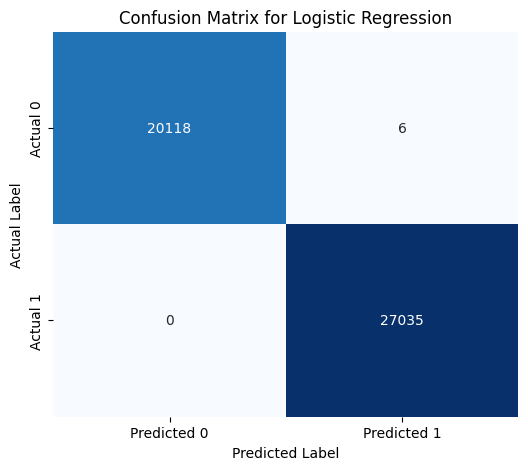

Confusion matrix plotted for Logistic Regression.


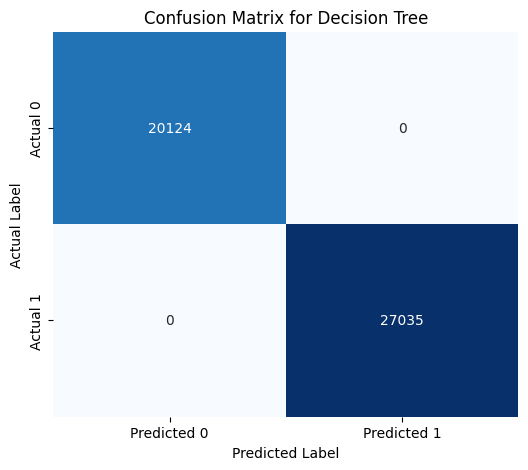

Confusion matrix plotted for Decision Tree.


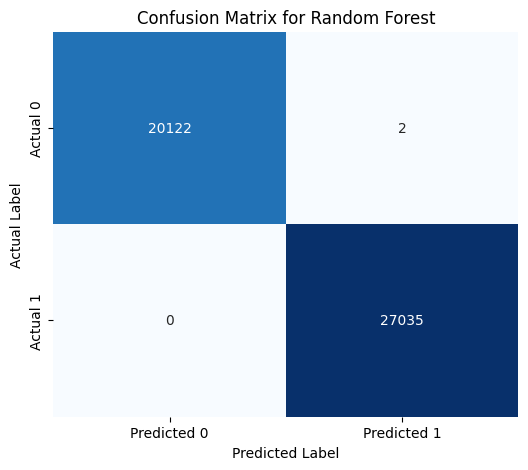

Confusion matrix plotted for Random Forest.


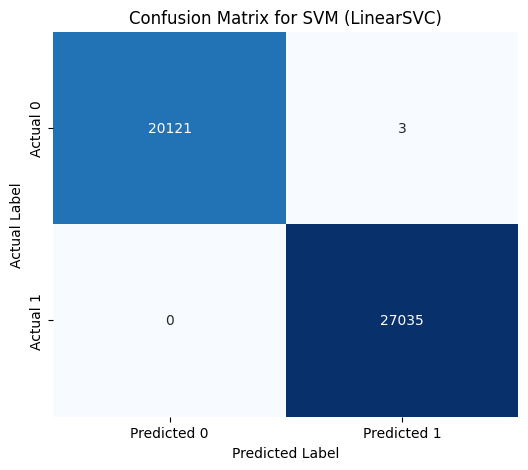

Confusion matrix plotted for SVM (LinearSVC).


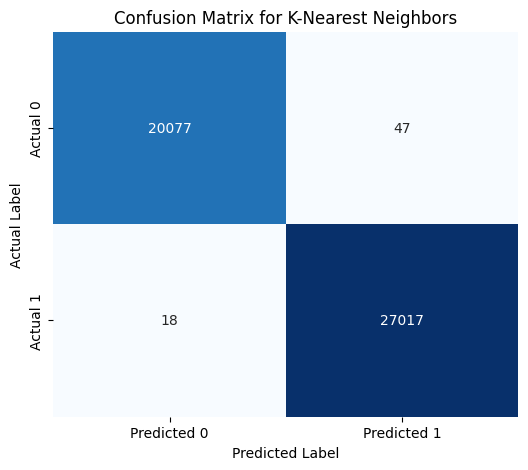

Confusion matrix plotted for K-Nearest Neighbors.


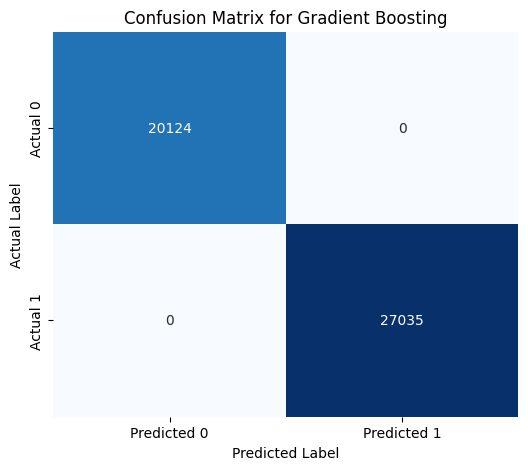

Confusion matrix plotted for Gradient Boosting.


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title(f'Confusion Matrix for {model_name}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

print("Libraries for confusion matrix and plotting imported. plot_confusion_matrix function defined.")

# Generate and plot confusion matrices for each model
models = {
    "Logistic Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "SVM (LinearSVC)": svm_model,
    "K-Nearest Neighbors": knn_model,
    "Gradient Boosting": gb_model
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    plot_confusion_matrix(y_test, y_pred, name)
    print(f"Confusion matrix plotted for {name}.")



Comparative Model Performance:
                     Accuracy  Precision    Recall  F1-Score   AUC-ROC
Decision Tree        1.000000   1.000000  1.000000  1.000000  1.000000
Gradient Boosting    1.000000   1.000000  1.000000  1.000000  1.000000
Random Forest        0.999958   0.999926  1.000000  0.999963  1.000000
SVM (LinearSVC)      0.999936   0.999889  1.000000  0.999945  1.000000
Logistic Regression  0.999873   0.999778  1.000000  0.999889  1.000000
K-Nearest Neighbors  0.998622   0.998263  0.999334  0.998798  0.999426

Best performing model: Decision Tree


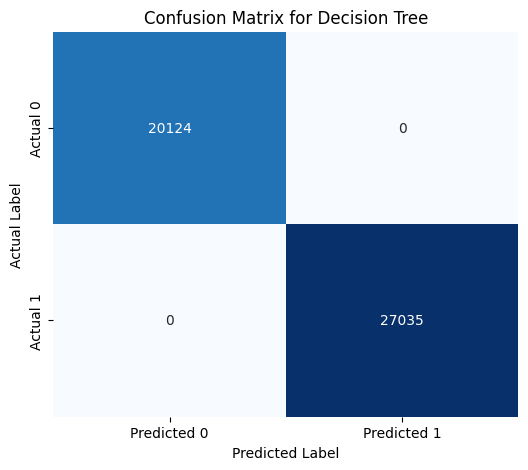

Confusion matrix for the best model (Decision Tree) plotted.


In [ ]:
import pandas as pd

# Convert model_results dictionary to a DataFrame
results_df = pd.DataFrame(model_results).T

# Sort the DataFrame by F1-Score, AUC-ROC, and Accuracy to identify the best model
results_df_sorted = results_df.sort_values(by=['F1-Score', 'AUC-ROC', 'Accuracy'], ascending=False)

print("\nComparative Model Performance:")
print(results_df_sorted)

# Identify the best performing model
best_model_name = results_df_sorted.index[0]
best_model = models[best_model_name]

print(f"\nBest performing model: {best_model_name}")

# Predict labels for the test set using the best model
y_pred_best_model = best_model.predict(X_test)

# Display the confusion matrix for the best model
plot_confusion_matrix(y_test, y_pred_best_model, best_model_name)
print(f"Confusion matrix for the best model ({best_model_name}) plotted.")

In [ ]:
print("Total number of 'safe' (0) and 'phishing' (1) URLs in the entire dataset:")
print(y.value_counts())

Total number of 'safe' (0) and 'phishing' (1) URLs in the entire dataset:
label
1    134850
0    100945
Name: count, dtype: int64
